In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '/home/jbreda/PROseq/scripts/Phase_to_LabColor')
from phase_to_labcolor import phase_to_labcolor as p2lc

In [2]:
genome = 'GRCm38'

# get gene gtf
infile_gtf = f"../resources/genome/{genome}/gene_annotation.gtf"
gene_gtf = pd.read_csv(infile_gtf, sep='\t', comment='#', header=None)
gene_gtf.columns = ['chrom','source','feature','start','end','score','strand','frame','attributes']
# parse the gtf's 9 th column (attributes sep by ;)
attributes = ['gene_id','gene_type','gene_name','transcript_id','transcript_type','transcript_name']
for att in attributes:
    gene_gtf[att] = gene_gtf['attributes'].str.extract(rf'{att} "(.*?)";')


In [3]:


# get extended kalman filter data
bin_size = 1000
infile_kalman = f"../results/{genome}/kalman/extended_kalman_on_chromosomes_bin{bin_size}bp.csv"
extended = pd.read_csv(infile_kalman, sep='\t')

# get bin phase amplitude
infile_bin_fw = f"../results/{genome}/phase_amp/bin_phase_amp_forward_10000bp.csv"
infile_bin_rv = f"../results/{genome}/phase_amp/bin_phase_amp_reverse_10000bp.csv"
bin_phase_amp = {}
bin_phase_amp['+'] = pd.read_csv(infile_bin_fw, sep='\t')
bin_phase_amp['-'] = pd.read_csv(infile_bin_rv, sep='\t')

# read gene phase amplitude
#infile_gene = f"../results/{genome}/phase_amp/gene_phase_amp.csv"
#gene_phase_amp = {}
#gene_phase_amp['proseq'] = pd.read_csv(infile_gene, sep='\t')



In [25]:
np.where(extended.LL == extended.LL.max())

(array([599450]),)

In [41]:
# compute numerical derivative of phi
pos = extended.start + bin_size/2
phi = extended.phi
k_eff = (phi[1:] - phi[:-1])/(pos[1:] - pos[:-1])

In [37]:
np.diff(phi) == k_eff

array([ True,  True,  True, ...,  True,  True,  True])

In [38]:
extended.

,chr,start,end,strand,LL,a,da,b,db,dab,k,dk,λ,dλ,amp,damp,phi,dphi
0,chr1,3058000,3059000,+,-24.981934,0.000465,0.009845,0.006882,0.009841,0.000010,0.000440,0.000004,-0.009976,0.009085,0.006898,0.140381,1.503367,14.384034
1,chr1,3106000,3107000,+,-24.689348,-0.000521,0.009715,0.008697,0.009694,0.000015,0.000357,0.000005,-0.009994,0.009074,0.008713,0.139423,1.630635,11.313023
2,chr1,3115000,3116000,+,-24.709992,-0.000219,0.009688,0.008399,0.009675,0.000010,0.000308,0.000003,-0.009962,0.009084,0.008402,0.139219,1.596872,11.715856
3,chr1,3120000,3121000,+,-24.651689,-0.000136,0.009679,0.008413,0.009669,0.000006,0.000369,0.000003,-0.009967,0.009085,0.008414,0.139142,1.587020,11.693421
4,chr1,3121000,3122000,+,-24.991911,-0.000162,0.009679,0.008346,0.009670,0.000006,0.000378,0.000001,-0.009975,0.009085,0.008348,0.139148,1.590213,11.785932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1741656,chrM,12000,13000,-,-6.311490,0.117526,0.004724,-0.131623,0.005501,-0.001239,0.033155,-0.003153,-0.001214,0.008789,0.176457,0.088020,5.441265,0.351081
1741657,chrM,13000,14000,-,-6.474089,0.117384,0.004878,-0.132048,0.005670,-0.001337,0.036166,-0.004009,-0.003030,0.008704,0.176679,0.088734,5.439066,0.353452
1741658,chrM,14000,15000,-,-6.515083,0.117839,0.005067,-0.133107,0.005885,-0.001471,0.039373,-0.005265,-0.004631,0.008446,0.177774,0.089503,5.437021,0.354279
1741659,chrM,15000,16000,-,-6.638349,0.119016,0.005364,-0.134974,0.006251,-0.001716,0.040902,-0.006652,-0.008271,0.008441,0.179952,0.090462,5.435041,0.353631


/tmp/ipykernel_391851/2548109481.py:135: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])


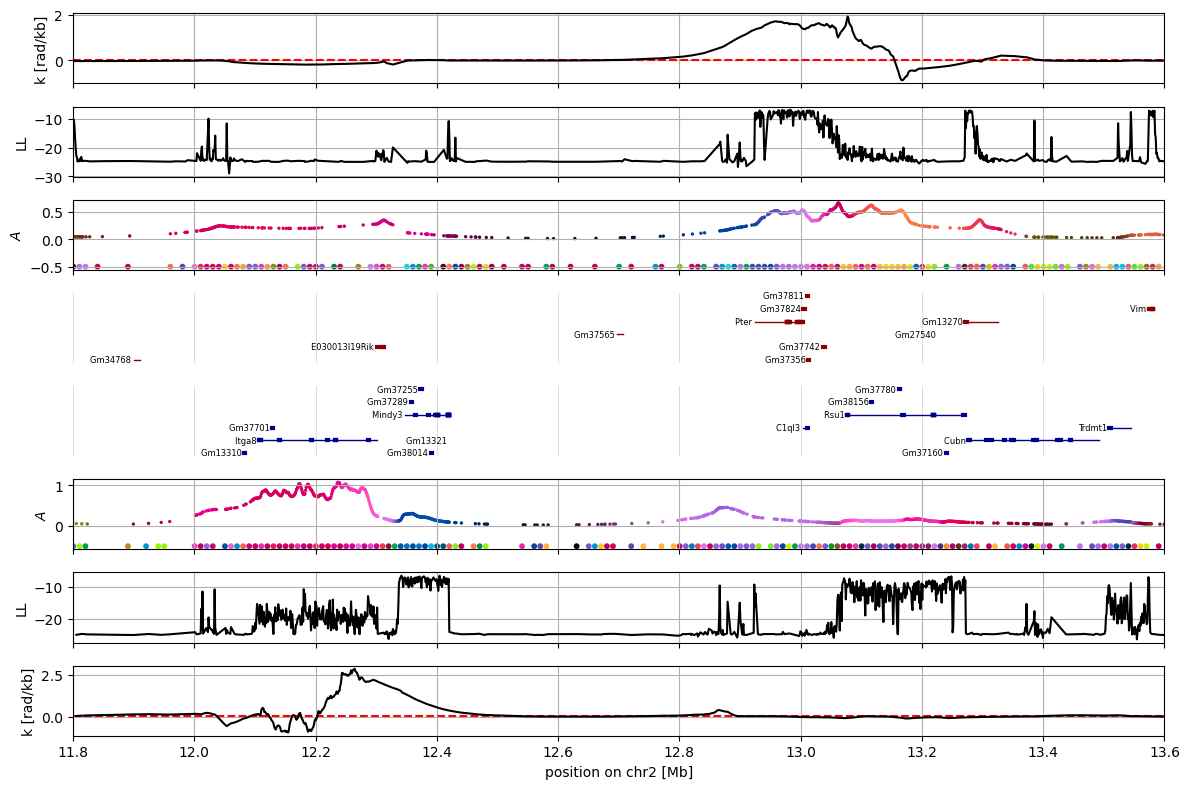

In [57]:
# removed regions :
# 'chr5:104_888_056:107_620_085',
# 'chr5:121_017_471:126_000_000',

Regions = ['chr2:11_800_000:13_600_000',
           'chr5:120_415_452:120_920_000',
           'chr7:19_557_000:20_000_000',
           'chr10:75_000_000:76_750_000',
           'chr12:28015438:29654150',
           'chr17:10_750_000:13_250_000',
           'chr17:34_783_585:35_070_714']

# k mean
ω = 2*np.pi/24 #  [rad/h] 
v_mean = 34 # [bp/s]
v_mean *= 1e-3 # [kb/s]
v_mean *= 3600 # [kb/h]
k_mean = ω/v_mean # [rad/kb]

for region in Regions[:1]:
    chrom, start, end = region.split(':')
    start = int(start)
    end = int(end)
    
    # plot : 2 strands * (k, phase, LL, genes)
    N_tracks = 4
    fig, axes = plt.subplots(nrows=2*N_tracks, ncols=1, figsize=(12, 8))
    fplus = N_tracks-1
    fminus = N_tracks
    for strand in ['+','-']:

        region_data = extended[(extended['chr'] == chrom) & (extended['start'] >= start) & (extended['end'] <= end) & (extended['strand'] == strand)]

        region_gtf = gene_gtf[(gene_gtf['chrom'] == chrom) & (gene_gtf['start'] >= start) & (gene_gtf['end'] <= end) & (gene_gtf['strand'] == strand)]

        x = region_data['start'].values+bin_size/2

        # elongation rate
        k = region_data['k'].values

        # phase
        phi = region_data['phi'].values
        A = region_data['amp'].values
        σ_A = region_data['damp'].values
        col = p2lc(phi,amp=A,th_amp=0.1)

        # k effective dphi/dx
        k_eff = (phi[1:] - phi[:-1])/(x[1:] - x[:-1]) # [rad/bp]
        k_eff *= 1e3 # [rad/kb]

        # bin phase
        x_bin = bin_phase_amp[strand][(bin_phase_amp[strand]['chr'] == chrom) & (bin_phase_amp[strand]['start'] >= start) & (bin_phase_amp[strand]['end'] <= end)]['start'].values + bin_size/2
        phi_bin = bin_phase_amp[strand][(bin_phase_amp[strand]['chr'] == chrom) & (bin_phase_amp[strand]['start'] >= start) & (bin_phase_amp[strand]['end'] <= end)]['phase'].values        
        amp_bin = bin_phase_amp[strand][(bin_phase_amp[strand]['chr'] == chrom) & (bin_phase_amp[strand]['start'] >= start) & (bin_phase_amp[strand]['end'] <= end)]['amplitude'].values
        col_bin = p2lc(phi_bin,amp=amp_bin,th_amp=0.2)

        # LL
        LL = region_data['LL'].values

        # get genes in region
        genes = region_gtf[(region_gtf['feature'] == 'gene')]['gene_id'].values

        # first track: genes
        if strand == '+':
            ax = axes[fplus]
            gene_color = 'darkred'
        elif strand == '-':
            ax = axes[fminus]
            gene_color = 'darkblue'
        
        y = 0
        for gene in genes:
            my_gene = region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'gene')]
            if len(my_gene) > 0:
                ax.plot(my_gene[['start','end']].values[0], [y,y], c=gene_color, linewidth=1)
                ax.text(my_gene[['start']].values[0], y, my_gene['gene_name'].values[0]+' ', fontsize=6,ha='right', va='center')

            my_exons = region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'exon')]
            for exon in my_exons.iterrows():
                ax.plot(exon[1][['start','end']].values, [y,y], c=gene_color, linewidth=3)
            
            y = (y+1)%6
        ax.set_xlim([start,end])
        for tick in ax.get_xticks():
            ax.axvline(tick, color='k', alpha=0.2, linewidth=0.5)
        ax.set_ylabel('genes')
        ax.axis('off')

        # next track Amp and phase
        if strand == '+':
            fplus -=1
            ax = axes[fplus]
        elif strand == '-':
            fminus +=1
            ax = axes[fminus]
        
        ax.scatter(x, A, c=col, s=2)
        ax.scatter(x_bin, -.5*np.ones(len(x_bin)), c=col_bin, s=10)
        ax.set_xticklabels([])
        ax.set_xlim([start,end])
        ax.set_ylabel(r'$A$')
        ax.grid()

        # next track LL
        if strand == '+':
            fplus -=1
            ax = axes[fplus]
        elif strand == '-':
            fminus +=1
            ax = axes[fminus]

        ax.plot(x, LL, 'k')
        ax.set_xticklabels([])
        ax.set_xlim([start,end])
        ax.set_ylabel('LL')
        ax.grid()

        # next track k
        if strand == '+':
            fplus -=1
            ax = axes[fplus]
        elif strand == '-':
            fminus +=1
            ax = axes[fminus]

        ax.hlines(k_mean, start, end, color='r', linestyle='--')
        ax.plot(x, k, 'k')
        #ax.plot(x[:-1]+(bin_size*1e-3)/2, k_eff)
        #ax.set_ylim([-5*k_mean,5*k_mean])
        ax.set_xticklabels([])
        ax.set_xlim([start,end])
        ax.set_ylabel('k [rad/kb]')
        ax.grid()
    
    ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
    ax.set_xlabel(f'position on {chrom} [Mb]')

    fig.tight_layout()
    fig.savefig(f"fig/extended_kalman/bin{bin_size}bp/{region.replace(':','_')}.pdf")


In [42]:
x

array([34784500., 34787500., 34791500., 34793500., 34795500., 34796500.,
       34797500., 34798500., 34799500., 34800500., 34801500., 34802500.,
       34803500., 34804500., 34805500., 34806500., 34807500., 34808500.,
       34809500., 34810500., 34811500., 34812500., 34813500., 34814500.,
       34815500., 34816500., 34817500., 34818500., 34819500., 34820500.,
       34821500., 34822500., 34823500., 34824500., 34825500., 34826500.,
       34827500., 34828500., 34829500., 34830500., 34831500., 34832500.,
       34833500., 34834500., 34835500., 34836500., 34837500., 34838500.,
       34839500., 34840500., 34841500., 34842500., 34843500., 34844500.,
       34845500., 34846500., 34847500., 34848500., 34849500., 34850500.,
       34851500., 34852500., 34853500., 34854500., 34855500., 34856500.,
       34857500., 34858500., 34859500., 34860500., 34861500., 34862500.,
       34863500., 34864500., 34865500., 34866500., 34867500., 34868500.,
       34869500., 34870500., 34871500., 34872500., 

In [28]:
φ

NameError: name 'φ' is not defined

In [18]:
k_mean

0.0021388838872479525

In [100]:
exon[1]

chrom                                                           chr2
source                                                        HAVANA
feature                                                         exon
start                                                       13456640
end                                                         13456692
score                                                              .
strand                                                             -
frame                                                              .
attributes         gene_id "ENSMUSG00000026726.10"; transcript_id...
gene_id                                        ENSMUSG00000026726.10
gene_type                                             protein_coding
gene_name                                                       Cubn
transcript_id                                   ENSMUST00000148506.1
transcript_type                                      retained_intron
transcript_name                   